# RandomForest Classifier

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report,confusion_matrix, roc_curve, auc
import numpy as np

In [5]:
df=pd.read_csv(r"C:\Users\Aantriksh\Desktop\AIML_Lab\datasets\city_day.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [6]:
df.dropna(inplace=True)
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
2123,Amaravati,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06,184.0,Moderate
2124,Amaravati,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08,197.0,Moderate
2125,Amaravati,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,0.12,198.0,Moderate
2126,Amaravati,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,0.07,188.0,Moderate
2127,Amaravati,2017-11-29,72.47,114.84,5.23,23.20,16.59,12.25,0.16,10.55,109.74,0.21,4.71,0.08,173.0,Moderate


In [7]:
def categorize_aqi(aqi_value):
    if pd.isna(aqi_value): # Handle potential NaN values if dropna wasn't fully effective
        return 'Unknown'
    if aqi_value <= 50:
        return 'Good'
    elif aqi_value <= 100:
        return 'Moderate'
    elif aqi_value <= 150:
        return 'Unhealthy for Sensitive Groups'
    elif aqi_value <= 200:
        return 'Unhealthy'
    elif aqi_value <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

In [8]:
df['AQI_Category'] = df['AQI'].apply(categorize_aqi)

In [9]:

# Let's simulate defining `scaled` and `y` for subsequent cells to work conceptually.
numerical_cols = df.select_dtypes(include=np.number).drop('AQI', axis=1, errors='ignore').columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numerical_cols])
scaled = pd.DataFrame(scaled_data, columns=numerical_cols)
y = df['AQI_Category'] # Or encoded version if needed

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(scaled,y,test_size=0.2,random_state=42)

In [11]:
params={'n_estimators':[50,100,150,200],
        'max_depth':[None,5,10,15,20],
        'min_samples_split':[5,10,15,20],
        'max_features':[5,10,15,20]}

In [12]:
class_rf=RandomForestClassifier()
rs=RandomizedSearchCV(class_rf,
                    param_distributions=params,
                    cv=3,
                    n_jobs=-1,
                    verbose=20)
rs.fit(x_train,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
                   param_distributions={'max_depth': [None, 5, 10, 15, 20],
                                        'max_features': [5, 10, 15, 20],
                                        'min_samples_split': [5, 10, 15, 20],
                                        'n_estimators': [50, 100, 150, 200]},
                   verbose=20)

In [13]:
def report(results, n_top=3):
    """Utility function to report best scores"""
    print(f"Reporting top {n_top} results:")
    for i in range(1, n_top + 1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print("Model with rank: {0}".format(i))
            print("Mean validation score: {0:.6f} (std: {1:.6f})".format(
                  results['mean_test_score'][candidate],
                  results['std_test_score'][candidate]))
            print("Parameters: {0}".format(results['params'][candidate]))
            print("")

In [14]:
report(rs.cv_results_, 3)

Reporting top 3 results:
Model with rank: 1
Mean validation score: 0.783281 (std: 0.008769)
Parameters: {'n_estimators': 150, 'min_samples_split': 10, 'max_features': 5, 'max_depth': 10}

Model with rank: 2
Mean validation score: 0.779672 (std: 0.005355)
Parameters: {'n_estimators': 150, 'min_samples_split': 10, 'max_features': 10, 'max_depth': None}

Model with rank: 3
Mean validation score: 0.778068 (std: 0.006354)
Parameters: {'n_estimators': 150, 'min_samples_split': 20, 'max_features': 5, 'max_depth': 20}



In [15]:
# Init and train the best model 
rf=RandomForestClassifier(**{'n_estimators': 150, 'min_samples_split': 5, 'max_features': 20, 'max_depth': 10}, random_state=42)
# Note: Fitting depends on x_train, y_train being defined correctly.
rf.fit(x_train,y_train) 

RandomForestClassifier(max_depth=10, max_features=20, min_samples_split=5,
                       n_estimators=150, random_state=42)

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Note: Predictions and evaluation depend on rf, x_test, y_test being defined correctly.
y_pred = rf.predict(x_test)
# Assuming predictions were made, calculate probabilities for metrics like ROC AUC if needed
y_pred_proba = rf.predict_proba(x_test) # Keep probabilities for all classes

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred)) # Add target_names=le.classes_ if using LabelEncoder
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7652243589743589

Classification Report:
                                precision    recall  f1-score   support

                          Good       0.84      0.69      0.76        94
                     Hazardous       0.81      0.85      0.83       102
                      Moderate       0.82      0.87      0.84       411
                     Unhealthy       0.61      0.53      0.57       152
Unhealthy for Sensitive Groups       0.75      0.79      0.77       357
                Very Unhealthy       0.71      0.62      0.66       132

                      accuracy                           0.77      1248
                     macro avg       0.76      0.73      0.74      1248
                  weighted avg       0.76      0.77      0.76      1248


Confusion Matrix:
[[ 65   0  29   0   0   0]
 [  0  87   0   0   0  15]
 [ 12   0 359   0  40   0]
 [  0   0   2  81  52  17]
 [  0   1  49  25 281   1]
 [  0  19   0  27   4  82]]


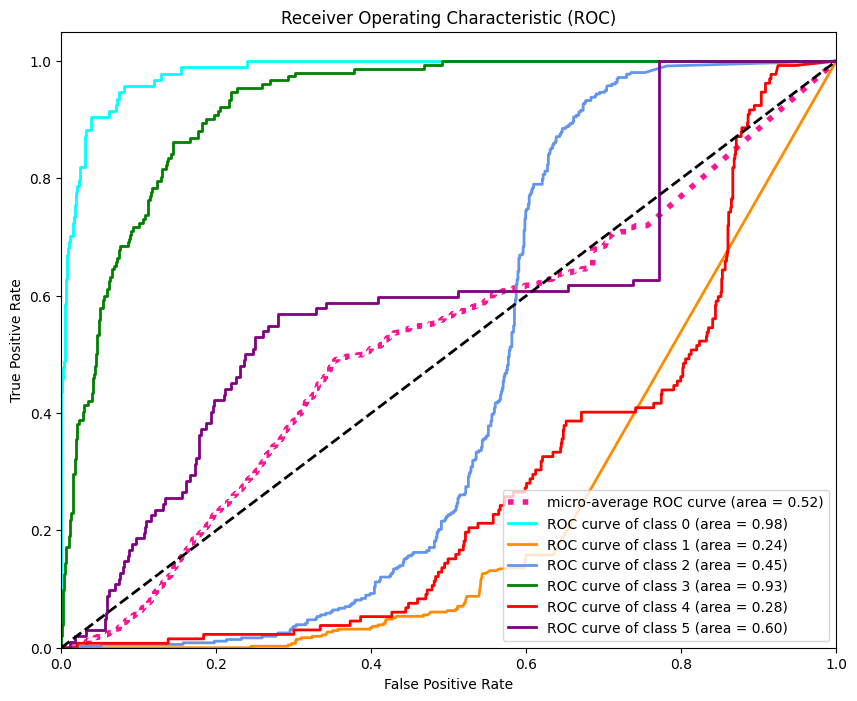

In [17]:
# Now we generate the ROC curve and AUC for each class
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn.metrics import roc_auc_score


# Binarize the output
y_test_bin = label_binarize(y_test, classes=['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous'])
n_classes = y_test_bin.shape[1]

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr["micro"], tpr["micro"], label='micro-average ROC curve (area = {0:0.2f})'
         ''.format(roc_auc["micro"]), color='deeppink', linestyle=':', linewidth=4)
for i, color in zip(range(n_classes), cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

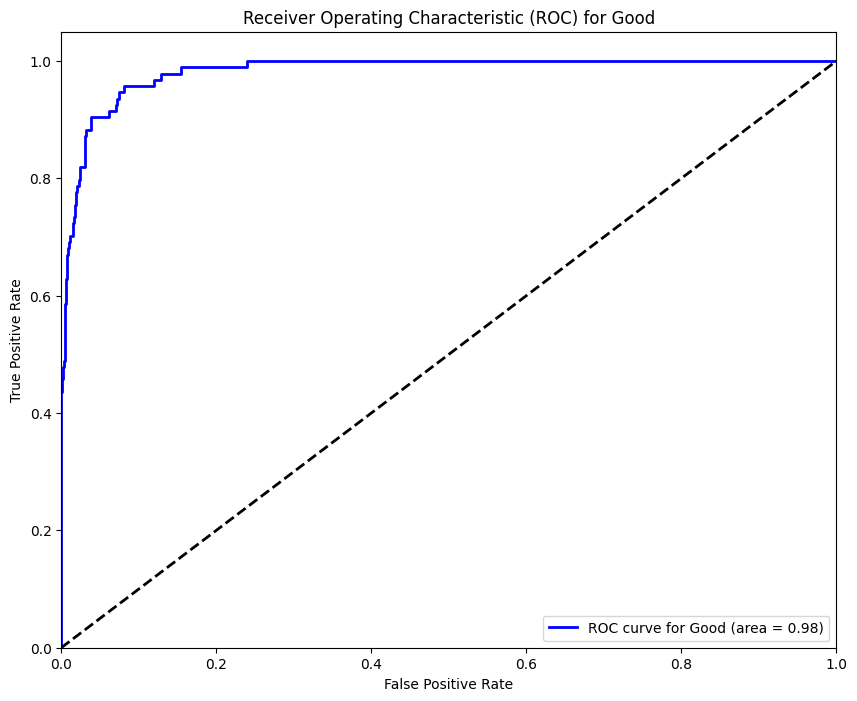

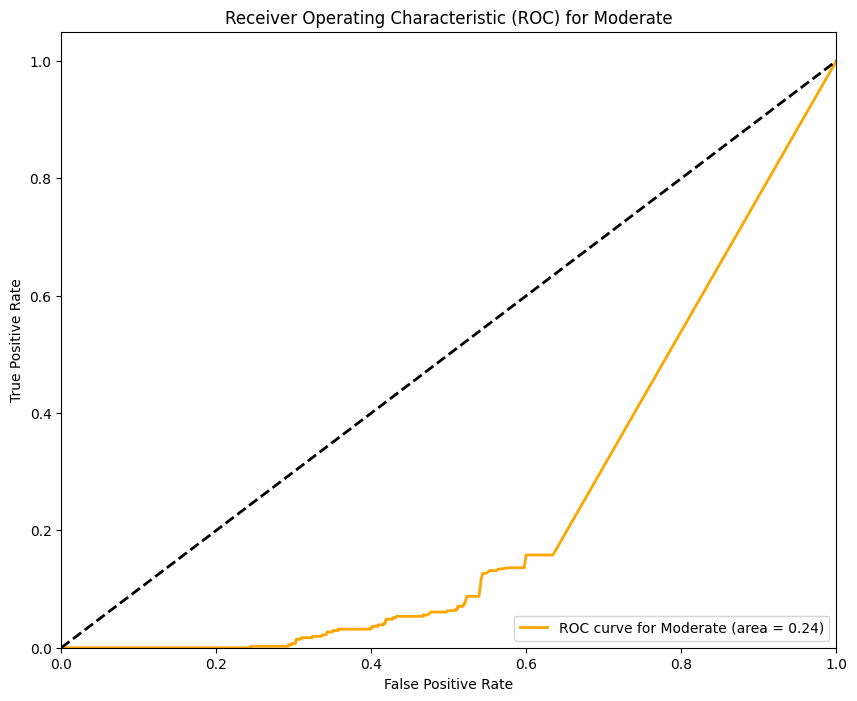

In [19]:
# roc plot for good and moderate separately
fpr_good, tpr_good, _ = roc_curve(y_test_bin[:, 0], y_pred_proba[:, 0])
roc_auc_good = auc(fpr_good, tpr_good)
plt.figure(figsize=(10, 8))
plt.plot(fpr_good, tpr_good, color='blue', lw=2, label='ROC curve for Good (area = {0:0.2f})'.format(roc_auc_good))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Good')
plt.legend(loc="lower right")
plt.show()

# roc plot for moderate
fpr_moderate, tpr_moderate, _ = roc_curve(y_test_bin[:, 1], y_pred_proba[:, 1])
roc_auc_moderate = auc(fpr_moderate, tpr_moderate)
plt.figure(figsize=(10, 8))
plt.plot(fpr_moderate, tpr_moderate, color='orange', lw=2, label='ROC curve for Moderate (area = {0:0.2f})'.format(roc_auc_moderate))
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) for Moderate')
plt.legend(loc="lower right")
plt.show()